In [2]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from utils.Files import *
pd.set_option('display.max_columns', None)

In [ ]:
MULTICLASS = False  # cada landmark ou apenas binário  
TILE_SIZE     = 0   # se for 0 não há implementaçaõ
AUG_PER_IMAGE = 0   # se for 0 não há implementação

In [4]:
images = [np.load(img) for img in getFiles('database/raw/images')]
masks  = [np.load(img) for img in getFiles('database/raw/masks')]

IMG_SIZE = images[0].shape[0]
images[:5]

[array([[[ 0.12120506,  0.17570351,  0.4359985 , ..., -0.4947749 ,
          -0.6476258 , -0.66195   ],
         [ 0.1122046 ,  0.38752872,  0.5579165 , ..., -0.42703027,
          -0.62235016, -0.69377184],
         [ 0.11782821,  0.5109103 ,  0.5682595 , ..., -0.37594628,
          -0.73534375, -0.94065976],
         ...,
         [-0.23042697, -0.32701367, -0.8466749 , ..., -0.59866023,
          -0.26966175,  0.6604995 ],
         [-0.3479929 , -0.4939739 , -0.6872361 , ..., -0.5468131 ,
          -0.2615065 ,  0.49023777],
         [-0.28028083, -0.5623336 , -0.76194334, ..., -0.41575906,
          -0.27286473,  0.31606558]],
 
        [[ 0.11168589,  0.20517224,  0.46182802, ..., -0.3388075 ,
          -0.73724127, -0.7908831 ],
         [ 0.03122767,  0.42496234,  0.67580825, ..., -0.23772597,
          -0.58448696, -0.7918161 ],
         [-0.00357361,  0.54627657,  0.7120623 , ..., -0.18555507,
          -0.72388   , -1.0191149 ],
         ...,
         [-0.11975164, -0.0105104

# VERIFICAÇÃO DE INTEGRIDADE

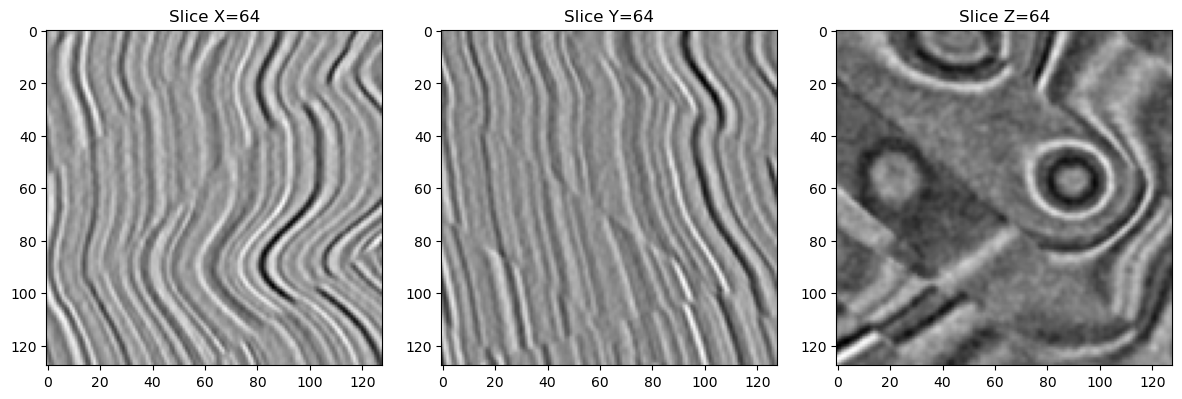

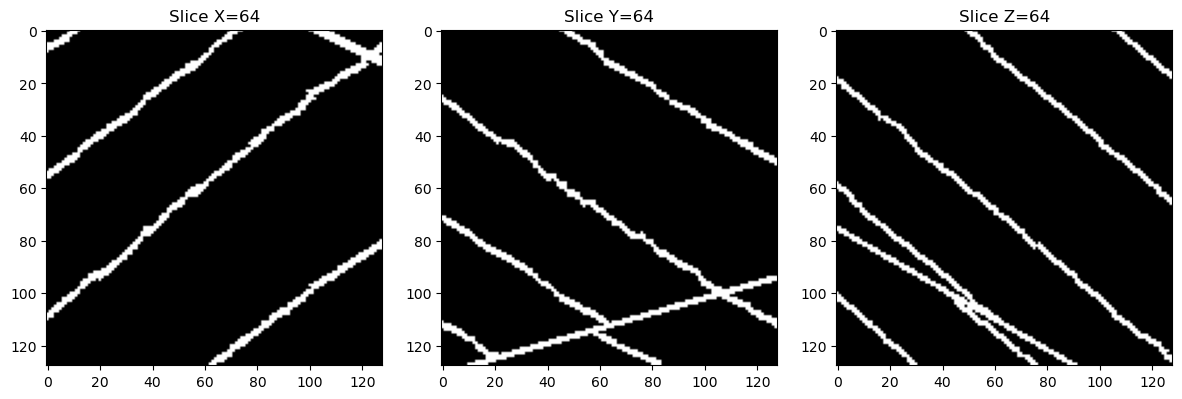

In [5]:
showTile(images[0])
showTile(masks[0])

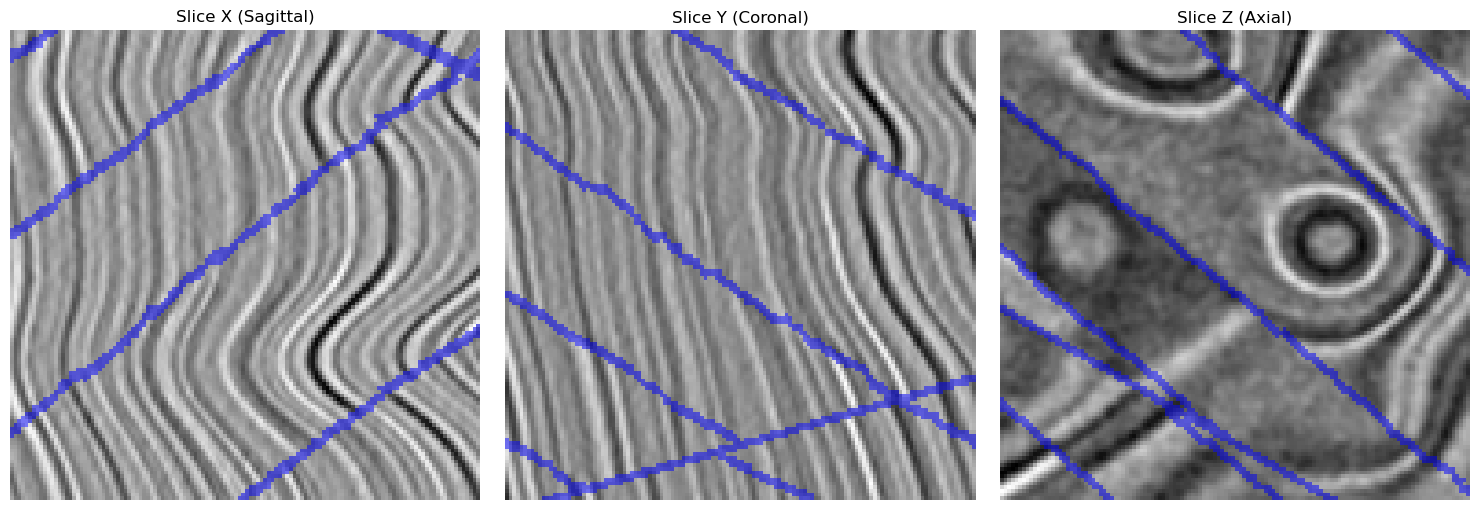

In [6]:
pasteMask(images[0], masks[0])

In [7]:
len(images) == len(masks)

True

# SPLITS DOS DADOS

In [8]:
VAL_SIZE  = 0.10
TEST_SIZE = 0.10
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [9]:
xTemp, xTest, yTemp, yTest = train_test_split(images, masks, test_size=TEST_SIZE, random_state=42)
del images, masks
xTrain, xVal, yTrain, yVal = train_test_split(xTemp, yTemp, test_size=VAL_SIZE, random_state=42)
del xTemp, yTemp

print(f'train: {len(yTrain)} files')
print(f'val:   {len(yVal)} files')
print(f'test:  {len(yTest)} files')

train: 176 files
val:   22 files
test:  22 files


# SALVANDO DADOS

In [10]:
class Saver:
    def __init__(self, target='processed'):
        self.DIR   = os.path.join(f'database', target)
        self.index = 0
        
        for split in ['train', 'val', 'test']:
            setFolder(f'{self.DIR}/{split}/images')
            setFolder(f'{self.DIR}/{split}/masks')

    def to(self, split, img, mask):
        path = os.path.join(self.DIR, split)
        self.index = (self.index + 1)
        
        if TILE_SIZE == 0:
            np.save(f'{path}/images/img_{self.index}.npy', img)
            np.save(f'{path}/masks/img_{self.index}.npy', mask)
            return
        
        imgs, masks = tiles.get(img, mask)
        for t, (img, mask) in enumerate(zip(imgs, masks)):
            np.save(f'{path}/images/img_{self.index}_tile_{t+1}.npy', img)
            np.save(f'{path}/masks/img_{self.index}_tile_{t+1}.npy', mask)

    def dataset(self, split, images, masks):
        for img, mask in zip(images, masks):
            self.to(split, img, mask)

            if AUG_PER_IMAGE > 0 and split == 'train':
                xData, yData = aug.compute(img, mask, AUG_PER_IMAGE)
                
                for img, mask in zip(xData, yData):
                    self.to(split, img, mask)

        total = os.listdir(f"{self.DIR}/{split}/images").__len__()
        print(f'{split}: {total} images')


saver = Saver('processed')
saver.dataset('train', xTrain, yTrain)
saver.dataset('val',   xVal,   yVal)
saver.dataset('test',  xTest,  yTest)
del xTrain, yTrain, xVal, yVal, xTest, yTest

train: 176 images
val: 22 images
test: 22 images


In [11]:
data = {
   'dataset': 'dataset1',
   'tile_size': TILE_SIZE, 
   'img_size': IMG_SIZE,
   'n_aug': AUG_PER_IMAGE, 
   'n_images': len(getAllFiles('database/raw/images')),
}

with open(f'database/info.json', 'w', encoding='utf-8') as file:
   json.dump(data, file, ensure_ascii=False, indent=4)

# VISUALIZAÇÃO

showing img 0


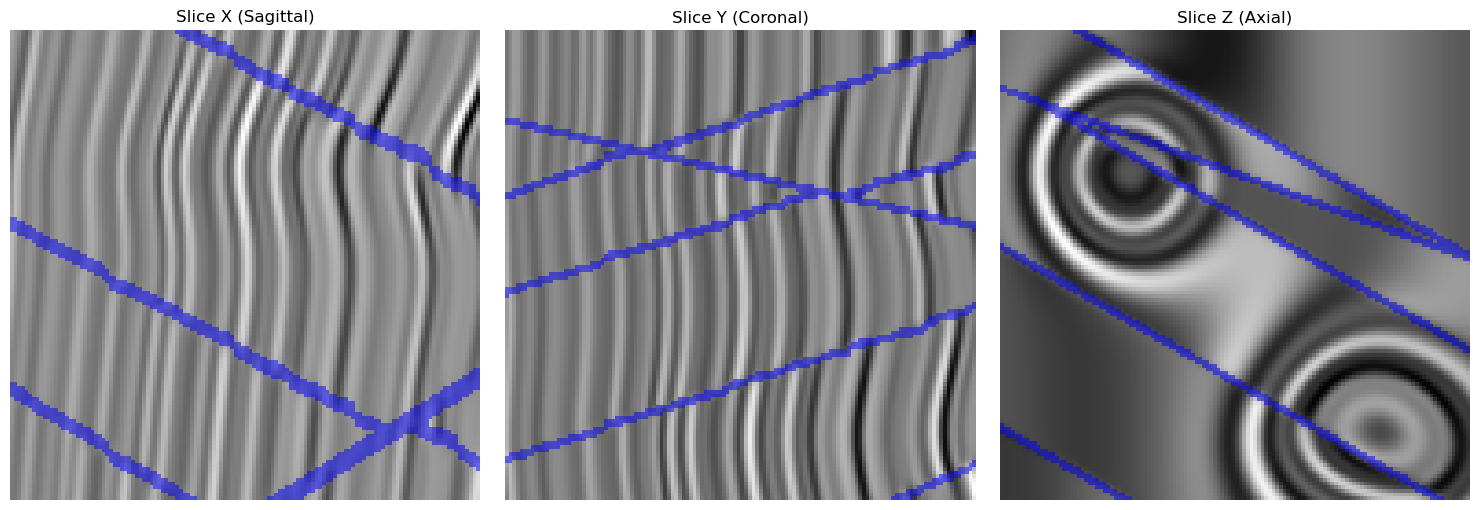

showing img 1


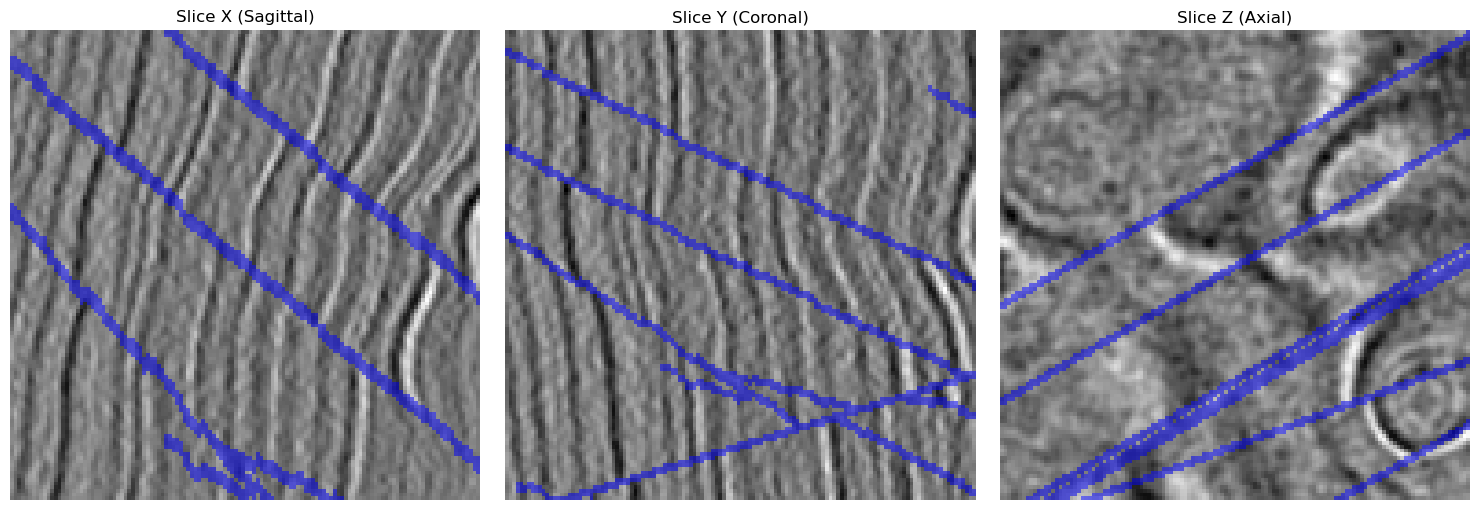

showing img 2


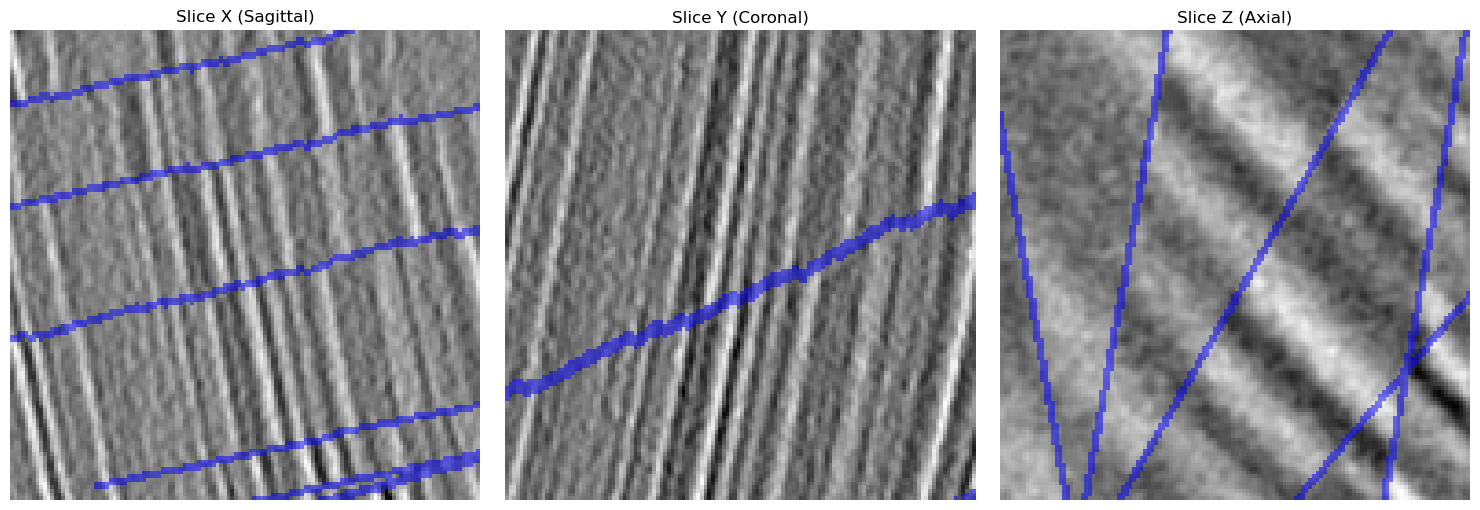

showing img 3


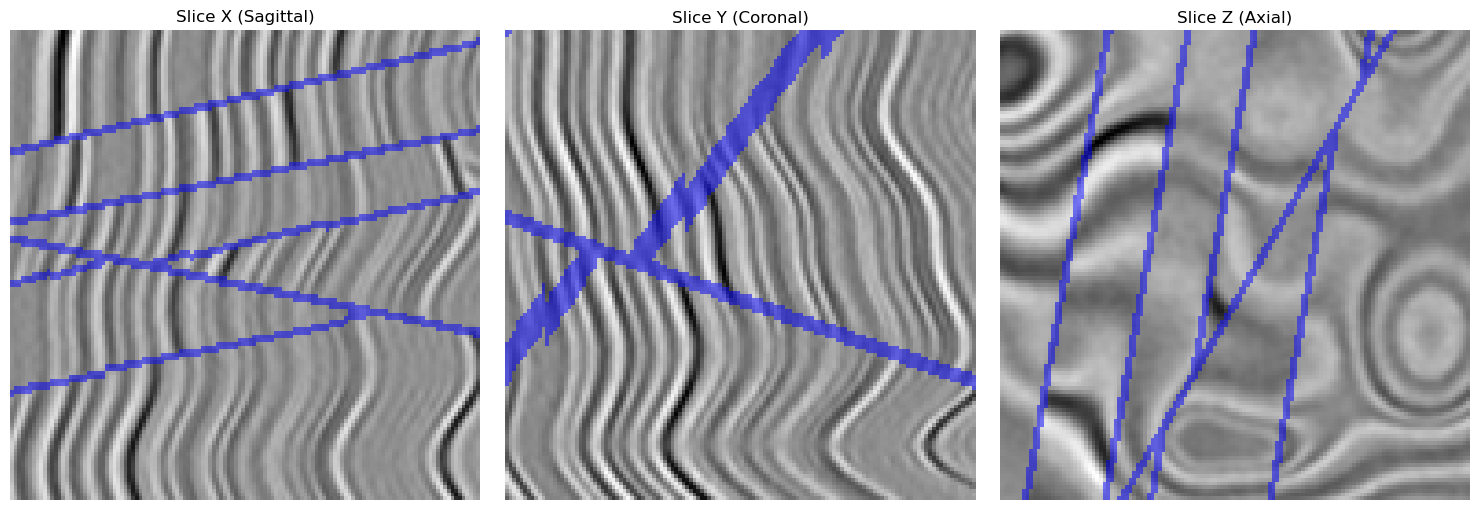

showing img 4


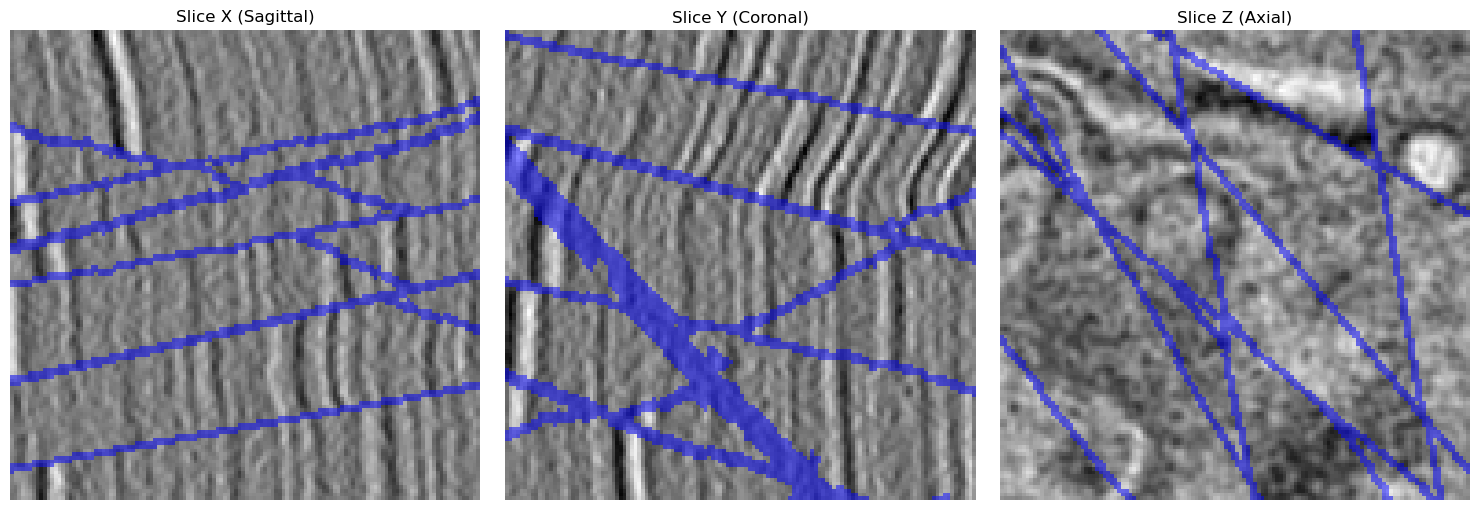

In [12]:
for i in range(5):
    print('showing img', i)
    img = np.load(getFile('database/processed/train/images', i))
    msk = np.load(getFile('database/processed/train/masks',  i))
    pasteMask(img, msk)